In [11]:
import importlib
import NeuralNetwork
import funcs
import plots

importlib.reload(NeuralNetwork)
importlib.reload(funcs)
importlib.reload(plots)
from NeuralNetwork import NeuralNetwork

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from collections import defaultdict
import numpy as np
from tqdm.auto import tqdm
import copy
import os

In [2]:
import importlib
import setup
importlib.reload(setup)
from setup import BATCH_SIZE

device = setup.get_device()
batch_size = BATCH_SIZE
train_dataset, val_dataset, test_dataset, fresh_dataset, train_loader, val_loader, test_loader, fresh_loader = setup.get_dataloaders()

device being used: cuda
train size: 172800, val size: 48000, fresh size: 19200, test size: 40000


## Activation analysis and Neuron Clustering

In [3]:
if os.path.exists("pruned_model.pth"):
    final_model = torch.load("pruned_model.pth", weights_only=False)
    final_model.eval()
    print("Loaded model from disk")
else:
    print("No final model saved on disk")

Loaded model from disk


We create a new data loader that does not shuffle the data so our instances match up with our data

In [4]:
analysis_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
analysis_model = copy.deepcopy(final_model)
analysis_model.eval()

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layer_stack): Sequential(
    (0): Linear(in_features=784, out_features=88, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=88, out_features=44, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=44, out_features=44, bias=True)
    (5): ELU(alpha=1.0)
    (6): Linear(in_features=44, out_features=44, bias=True)
    (7): ELU(alpha=1.0)
    (8): Linear(in_features=44, out_features=10, bias=True)
  )
)

In [5]:
layer_data_analysis = analysis_model.get_layer_data(analysis_loader)

  0%|          | 0/44 [00:00<?, ?it/s]

In [6]:
for key, value in layer_data_analysis.items():
    print(f"{key} has shape: {value['post_activation'].shape}")

layer_0 has shape: torch.Size([172800, 88])
layer_1 has shape: torch.Size([172800, 44])
layer_2 has shape: torch.Size([172800, 44])
layer_3 has shape: torch.Size([172800, 44])


In [7]:
layer_data_test = layer_data_analysis.copy()
layer_data_test.pop("layer_0")
for key, value in layer_data_test.items():
    print(f"{key} has shape: {value['post_activation'].shape}")

layer_1 has shape: torch.Size([172800, 44])
layer_2 has shape: torch.Size([172800, 44])
layer_3 has shape: torch.Size([172800, 44])


In [ ]:
# === Structural diagnostic: connected components via cluster_neurons_fabio ===
cluster_map_diag, layer_mapping_diag, _ = funcs.cluster_neurons_fabio(
    layer_data_test, min_clusters=1, max_clusters=50
)

print(f"Found {len(cluster_map_diag)} NMF-merged cluster(s) from structural components.")
print()

# Decode layer membership for each cluster
def _layers_spanned(neuron_indices, layer_mapping):
    layers = set()
    for gi in neuron_indices:
        for lname, start, end in layer_mapping:
            if start <= gi < end:
                layers.add(lname)
                break
    return sorted(layers)

for cid in sorted(cluster_map_diag):
    neurons = cluster_map_diag[cid]
    layers  = _layers_spanned(neurons, layer_mapping_diag)
    print(f"  Cluster {cid}: {len(neurons)} neurons  |  layers: {layers}")

## CLustering

In [ ]:
cluster_map, layer_mapping, all_neuron_activations = funcs.cluster_neurons_fabio(
    layer_data_test, min_clusters=1, max_clusters=50
)
layer_cluster_map = {"full_model": cluster_map}

## Cluster selectivity analysis

In [ ]:
labels = []
images = []
for X, y in tqdm(analysis_loader):
    labels.append(y)
    images.append(X)
labels = torch.cat(labels, dim=0)
images = torch.cat(images, dim=0)

  0%|          | 0/44 [00:00<?, ?it/s]

In [ ]:
selectivity_by_layer = {}
for layer_name, layer_clusters in layer_cluster_map.items():
    selectivity_by_layer[layer_name] = funcs.compute_cluster_selectivity(layer_clusters, all_neuron_activations, labels)


=== full_model ===


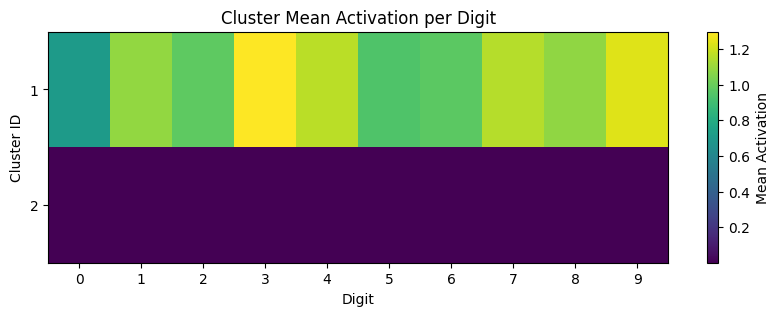

In [ ]:
for layer_name, selectivity_results in selectivity_by_layer.items():
    print(f"\n=== {layer_name} ===")
    plots.plot_cluster_activation_heatmap(selectivity_results)

## Cluster ablation

In [ ]:
cluster_results_by_layer = {}
for layer_name, layer_clusters in layer_cluster_map.items():
    layer_results = {}
    for cluster_id, neuron_indices in layer_clusters.items():
        per_class_acc = funcs.cluster_criticality_per_class(
            analysis_model,
            neuron_indices,
            layer_mapping,
            val_loader,
            cluster_id,
            device=device
        )
        layer_results[cluster_id] = per_class_acc
    cluster_results_by_layer[layer_name] = layer_results


--- Calculating pre and post-ablation accuracy for cluster 1 ---


  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]


--- Calculating pre and post-ablation accuracy for cluster 2 ---


  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]


=== full_model ===


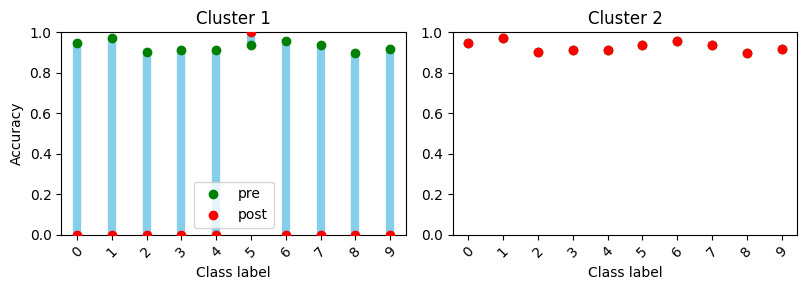

In [ ]:
for layer_name, cluster_results in cluster_results_by_layer.items():
    print(f"\n=== {layer_name} ===")
    plots.plot_cluster_accuracy_bars(cluster_results, target_labels=list(range(10)))

## Prototype and difference map plots

In [ ]:
all_prototypes_by_layer = {}
for layer_name, layer_clusters in layer_cluster_map.items():
    all_prototypes_by_layer[layer_name] = funcs.compute_prototypes_all_clusters(
        cluster_map=layer_clusters,
        all_activations=all_neuron_activations,
        images=images,
        top_frac=0.1,
        use_global_mean=True
    )

In [12]:
import importlib, plots, activation_maximization
importlib.reload(activation_maximization)
importlib.reload(plots)


<module 'plots' from 'c:\\Users\\fabio\\vu_uni\\machine learning\\actual files\\Project-ML\\plots.py'>

# Activation Maximization

Each image is synthesized from scratch by adjusting pixels until a cluster fires maximally. It shows the pure pattern a cluster is tuned to detect, free from the structure of any real digit.

**White** the cluster identifies a shape he wants

**Black** the cluster will give a "this is clearly not my job" signal (ie if there is something there he knows that for sure that's not his shape)

**Grey** the cluster does not care about that region


=== full_model ===


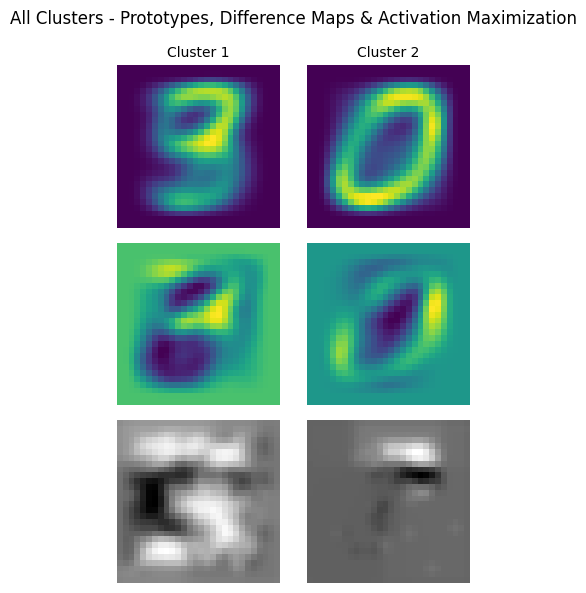

In [ ]:
for layer_name, all_prototypes in all_prototypes_by_layer.items():
    print(f"\n=== {layer_name} ===")
    plots.plot_cluster_prototypes_and_diff_all(
    all_prototypes,
    final_model,
    cluster_map,
    layer_mapping
)

In [ ]:
import importlib, network_map
importlib.reload(network_map)

# Interactive (Plotly) — single click: hide/show, double click: isolate cluster
network_map.draw_network_interactive(final_model, mode='clusters',
                                     cluster_map=cluster_map,
                                     layer_mapping=layer_mapping,
                                     ignore_layers=[0, 4])

# Static — connected components
network_map.draw_network(final_model, ignore_layers=[0, 4])

# Static — clusters
network_map.draw_network(final_model, mode='clusters',
                         cluster_map=cluster_map,
                         layer_mapping=layer_mapping,
                         ignore_layers=[0, 4])